## Exercício
Treinar um modelo preditivo de calssificalçao usando Regressão Logística (diretamente do sklearn) para prever se a rede elétrica esta "estável" ou "instável" com base no dataset: "https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data"

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Algorítmo de Regressão Logística
from sklearn.linear_model import LogisticRegression
# Separação de dados de treino e testes (X_train, X_test, Y_train, Y_test)
from sklearn.model_selection import train_test_split
# Métricas e avaliação do modelo
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



# Carregamento dos dados e Criação do Dataframe:

In [27]:
dados = pd.read_csv('https://raw.githubusercontent.com/Eric-Hernandes-Penhalbel/Machine_Learning-checkpoint2/refs/heads/main/Data_for_UCI_named.csv')

In [28]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [29]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [30]:
# Para colunas Numéricas
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [31]:
# Estatísticas descritivas
# Para colunas categóricas
dados.describe(include="object")

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [32]:
# Quais classes temos na coluna "stabf"
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [33]:
# Quantos Resgistros de cada classe temos na coluna "stabf"
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


In [34]:
# Classe A -----> 9990
# Classe B -----> 10

In [35]:
# Dados de entrada -----> Features ------> Variável Independente ---------> DataFrame X (Maiusculo)
X = dados.drop(['stab', 'stabf'], axis = 1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [36]:
# Dados de saída ------------> Target -----------> Variável dependente ----------> array y (minusculo)
y = dados['stabf']
y.head()

,stabf
0,unstable
1,stable
2,unstable
3,unstable
4,unstable


In [37]:
# Separação de dados de treino e teste ------------> train_test_split
# X_train, X_teste, Y_train, Y_teste
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=17)

In [38]:
X.shape

(10000, 12)

In [39]:
X_train.shape

(8000, 12)

In [40]:
X_test.shape

(2000, 12)

# Treinamento do modelo Preditivo de Classificação:

In [41]:
# Instanciando o modelo com base no algoritmo logistic Regression
modelo_LR = LogisticRegression()

In [42]:
# Treinamento do modelo:
modelo_LR.fit(X_train, Y_train)

LogisticRegression()

In [43]:
# Gerando as previsões:
y_predict = modelo_LR.predict(X_test)
y_predict

array(['unstable', 'unstable', 'unstable', ..., 'stable', 'unstable',
       'unstable'], dtype=object)

In [44]:
# Avaliar o modelo (Somente a acurácia):
acuracia = 100 * accuracy_score(Y_test, y_predict)
print(f'A acurácia do modelo baseado em Regressão Logística é de: {acuracia:.2f}%')

A acurácia do modelo baseado em Regressão Logística é de: 82.45%


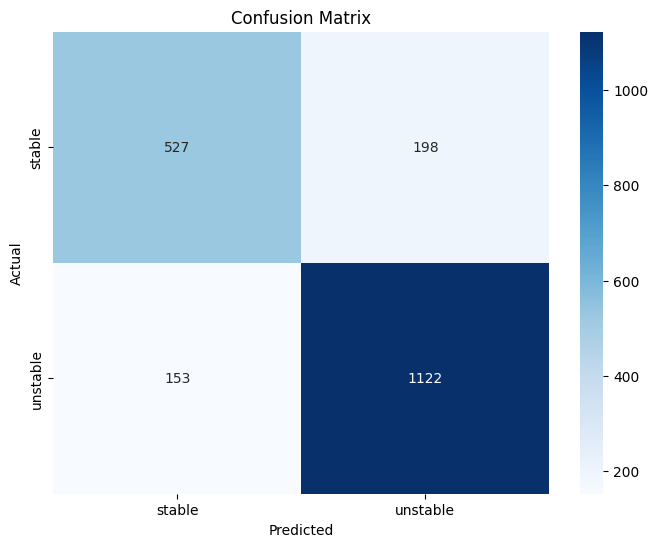

In [46]:
# Matriz de confusão usando o matplotlib e o seaborn
cm = confusion_matrix(Y_test, y_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_LR.classes_, yticklabels=modelo_LR.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()